# Vietnamese Handwriting Sheet (All Bold)

This notebook generates a Vietnamese handwriting sheet where all practice text uses the same bold style as the reference text.

In [4]:
from pathlib import Path
import sys

from IPython.display import Image, display
from reportlab.lib.pagesizes import A4
from reportlab.pdfgen import canvas

In [8]:
from types import SimpleNamespace

# Resolve project root when running from either workspace root or notebooks/.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Force PyMuPDF as fitz to avoid conflicts with the legacy fitz package.
import pymupdf
sys.modules["fitz"] = pymupdf

from src.utils.config import SheetConfig
from src.utils.handwriting_sheet_generation import (
    _convert_pdf_to_png,
    is_vietnamese_font,
    set_font,
)

In [9]:
sheet_cfg = SheetConfig()
sheet_cfg.vi_filename = "vietnamese_sheet_all_bold.pdf"
sheet_cfg.font_name = "vietnamese_sheet_bold"

# Keep reference text from config class, and use it as the source text for generation.
REF_TEXT = sheet_cfg.vi_text.strip()

cfg = SimpleNamespace(sheet=sheet_cfg)

FONT_PATH = PROJECT_ROOT / "data/reference/arialbd.ttf"
if not FONT_PATH.exists():
    raise FileNotFoundError(
        f"Missing font file at: {FONT_PATH}"
    )

if not is_vietnamese_font(str(FONT_PATH), cfg):
    raise ValueError(
        "The selected font does not support all Vietnamese chars in REF_TEXT."
    )

In [10]:
def create_vietnamese_sheet_all_bold(font_path: str, config: object, text: str):
    """Generate Vietnamese sheet with all repeated samples in the same bold style."""
    pdf_path = Path(config.sheet.save_path) / config.sheet.vi_filename

    pdf = canvas.Canvas(str(pdf_path), pagesize=A4)
    set_font(pdf, font_path, config)

    left_half = True
    x_pos = config.sheet.margin_left
    y_pos = config.sheet.margin_top

    for vi_token in [token for token in text.split() if token]:
        x = x_pos
        right_limit = (
            config.sheet.divide_vertical
            if left_half
            else config.sheet.margin_right
        )

        offset = config.sheet.font_size * 0.1
        pdf.setStrokeColorRGB(0.9, 0.9, 0.9)
        pdf.line(x_pos - 5, y_pos - offset, right_limit - 5, y_pos - offset)

        # Force all practice text to match the bold reference style.
        pdf.setFillColorRGB(0, 0, 0)
        while x <= (right_limit - 10):
            pdf.drawString(x, y_pos, vi_token)
            x += config.sheet.word_spacing

        pdf.setStrokeColorRGB(0.2, 0.2, 0.2)
        pdf.line(config.sheet.divide_vertical, 830, config.sheet.divide_vertical, 10)

        y_pos -= config.sheet.line_spacing
        if y_pos < config.sheet.margin_bottom:
            if left_half:
                x_pos = config.sheet.divide_vertical + 10
                y_pos = config.sheet.margin_top
                left_half = False
            else:
                left_half = True
                x_pos = config.sheet.margin_left
                y_pos = config.sheet.margin_top
                pdf.showPage()
                set_font(pdf, font_path, config)

    pdf.save()
    _convert_pdf_to_png(str(pdf_path))
    return pdf_path

Saved PDF: /home/tp_ubuntu/unsorted/handwriting-recognition/data/user_samples/vietnamese_sheet_all_bold.pdf
Generated PNG pages:
 - /home/tp_ubuntu/unsorted/handwriting-recognition/data/user_samples/vietnamese_sheet_all_bold_page_1.png
 - /home/tp_ubuntu/unsorted/handwriting-recognition/data/user_samples/vietnamese_sheet_all_bold_page_2.png
 - /home/tp_ubuntu/unsorted/handwriting-recognition/data/user_samples/vietnamese_sheet_all_bold_page_3.png


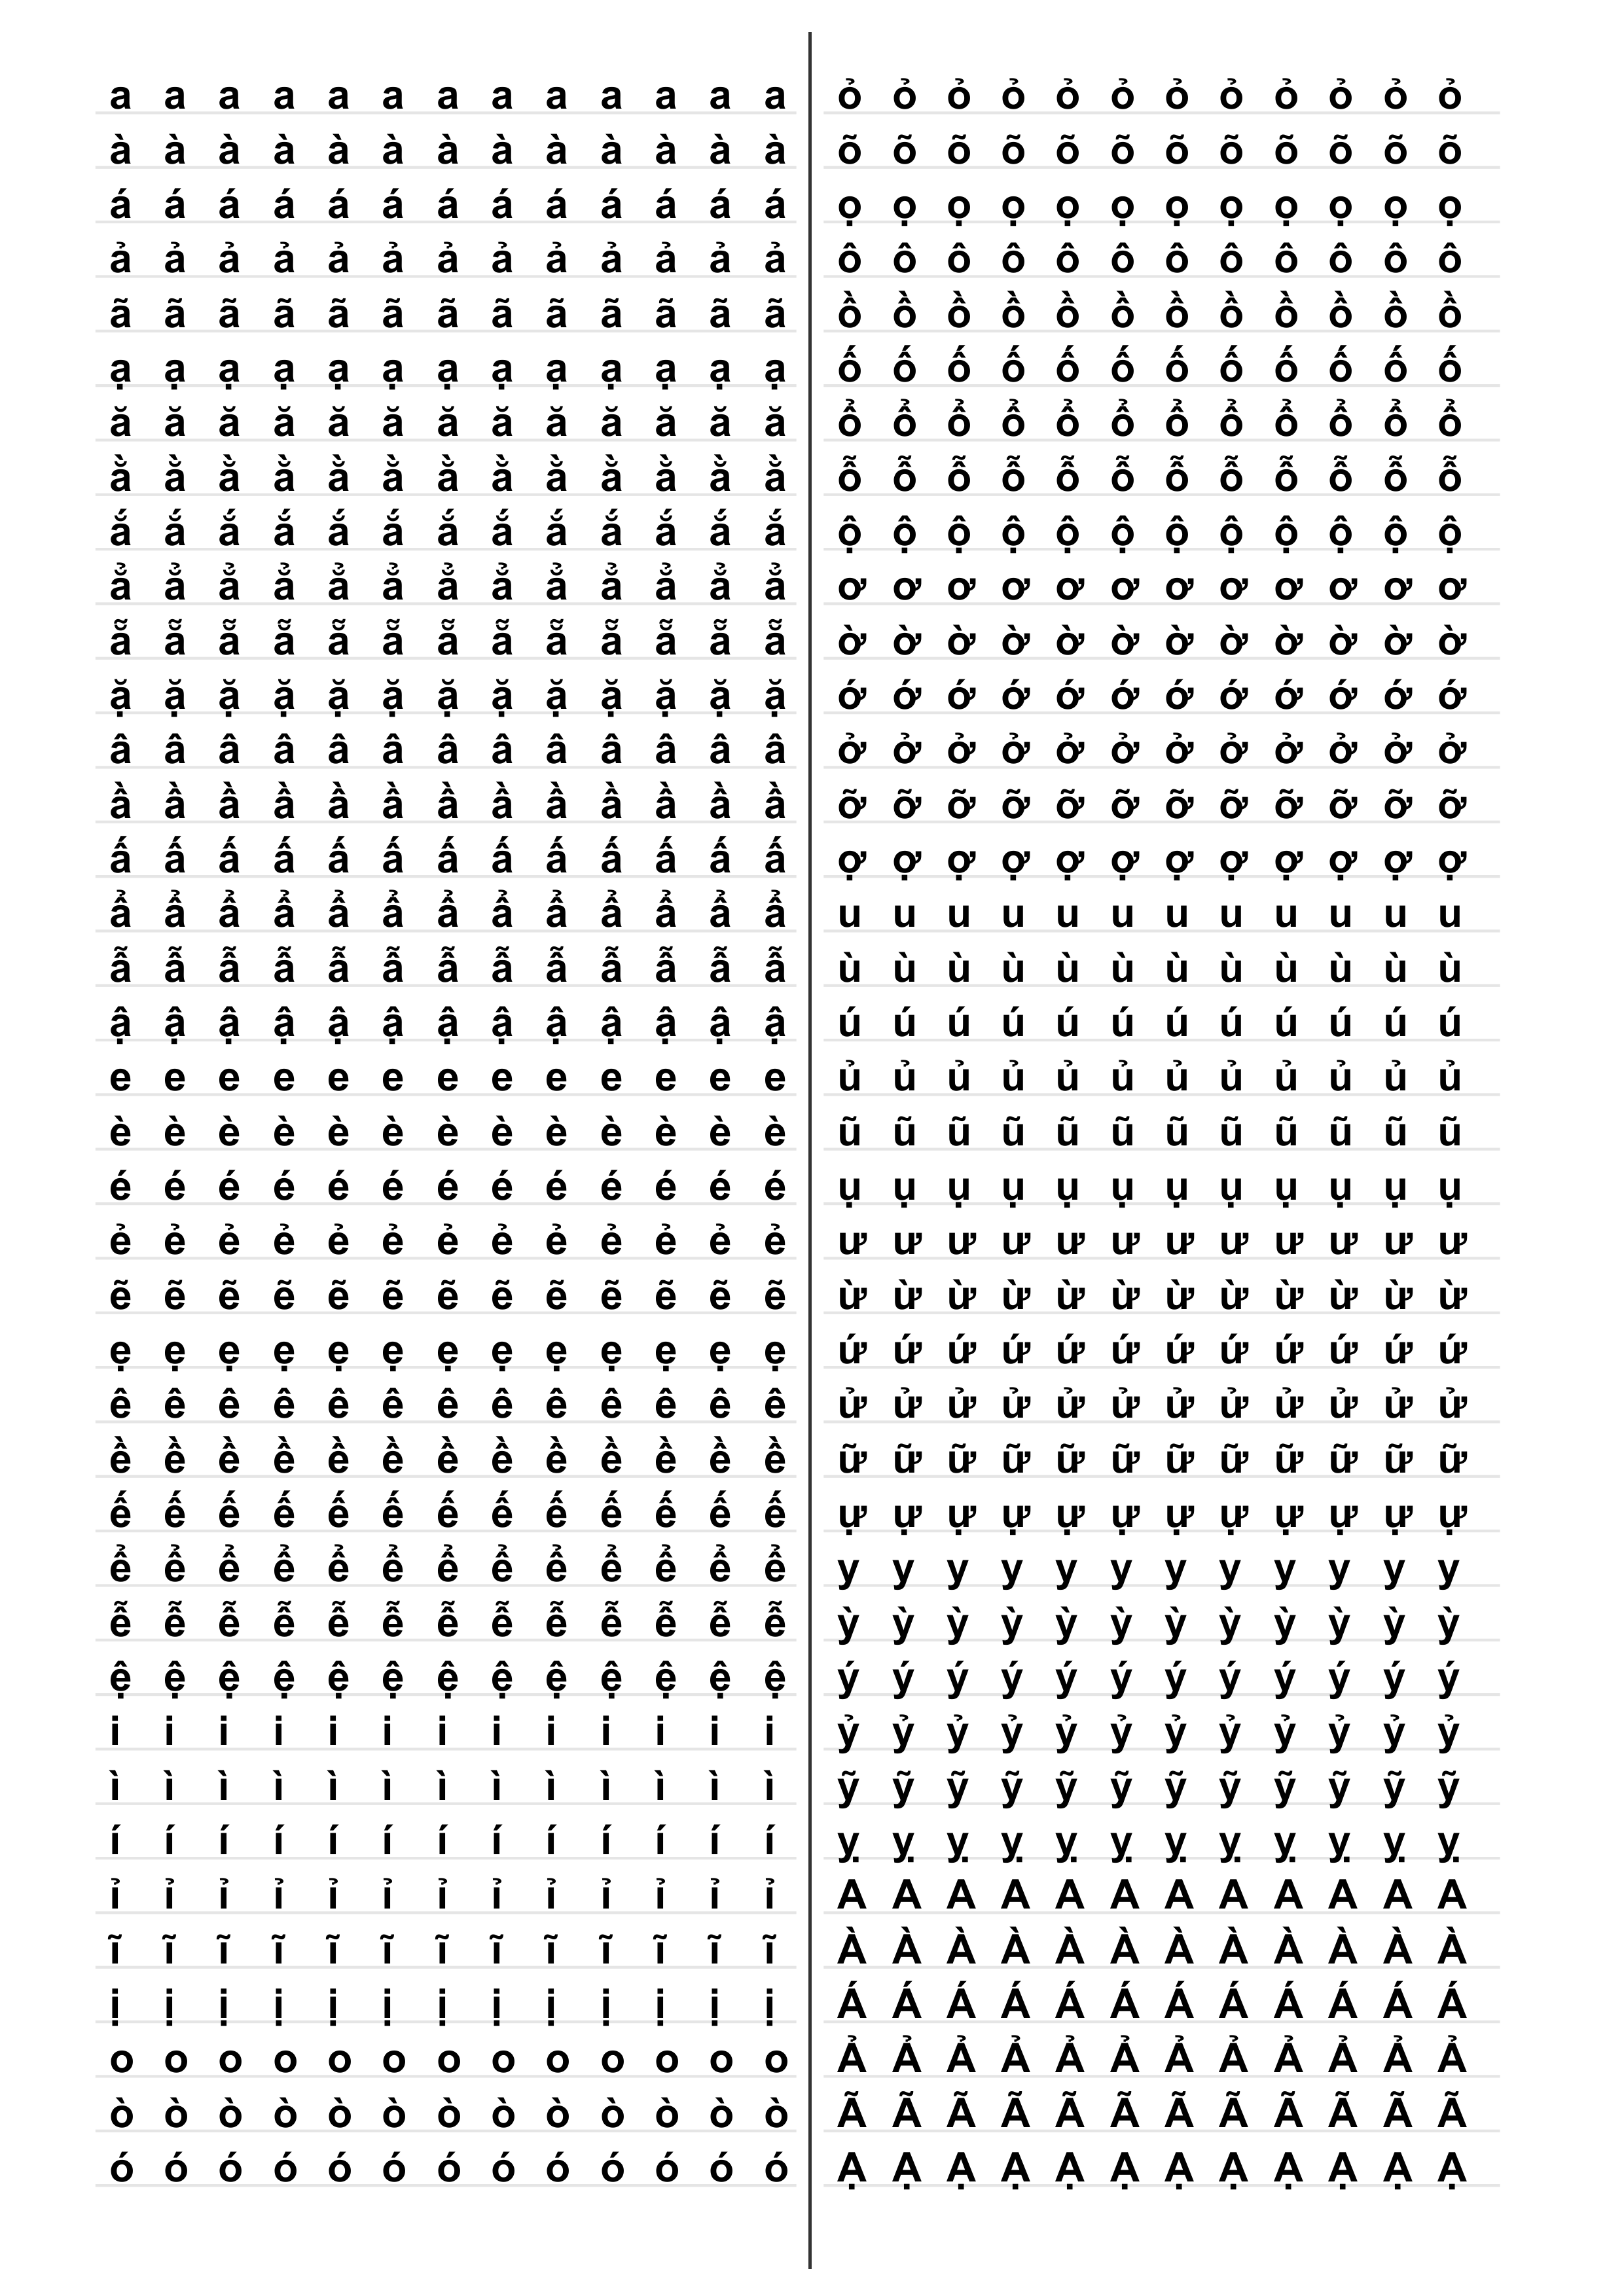

In [11]:
pdf_path = create_vietnamese_sheet_all_bold(str(FONT_PATH), cfg, REF_TEXT)
print(f"Saved PDF: {pdf_path}")

png_files = sorted(pdf_path.parent.glob(f"{pdf_path.stem}_page_*.png"))
print("Generated PNG pages:")
for p in png_files:
    print(" -", p)

if png_files:
    display(Image(filename=str(png_files[0])))